# Controlled ResNet-18 Fine-Tuning Baseline

This notebook evaluates whether limited supervised fine-tuning improves cross-script writer identification over the frozen linear-probe baseline.

## Protocol

- Training: Arabic variable-text and same-text pages
- Validation: English variable-text pages
- Final test: English same-text pages
- Writers: the same 226 development writers
- Backbone: ImageNet-pretrained ResNet-18
- Trainable components: ResNet layer 4 and the writer-classification head

The official writer-disjoint validation and test writers remain untouched for later writer-verification experiments.

## Goals

- Reproduce the linear-probe data protocol
- Fine-tune only the final ResNet feature block
- Use separate learning rates for the backbone and classifier
- Select the best checkpoint using English validation performance
- Compare fine-tuning with the frozen linear-probe baseline
- Examine cross-script generalization and prediction collapse

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader
from torchvision.models import ResNet18_Weights, resnet18

from handwriting_cross_script_research import QUWIDataset

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

PROJECT_ROOT = Path.cwd().resolve()

while PROJECT_ROOT != PROJECT_ROOT.parent and not (
    PROJECT_ROOT / "pyproject.toml"
).exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

assert (PROJECT_ROOT / "pyproject.toml").exists()

IMAGE_DIR = (
    Path.home()
    / "Documents"
    / "Handwriting"
    / "QUWI"
    / "extracted"
    / "images"
)

SPLIT_PATH = (
    PROJECT_ROOT
    / "splits"
    / "quwi_writer_disjoint_split_seed42.csv"
)

LINEAR_PROBE_CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "supervised_baseline"
    / "resnet18_linear_probe_best.pt"
)

LINEAR_PROBE_SUMMARY_PATH = (
    PROJECT_ROOT
    / "reports"
    / "supervised_baseline"
    / "resnet18_linear_probe_summary.json"
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Project root:", PROJECT_ROOT)
print("Image directory exists:", IMAGE_DIR.exists())
print("Split file exists:", SPLIT_PATH.exists())
print(
    "Linear-probe checkpoint exists:",
    LINEAR_PROBE_CHECKPOINT_PATH.exists(),
)
print(
    "Linear-probe summary exists:",
    LINEAR_PROBE_SUMMARY_PATH.exists(),
)
print("Random seed:", SEED)
print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Project root: /home/arijit/Documents/handwriting-cross-script-research
Image directory exists: True
Split file exists: True
Linear-probe checkpoint exists: True
Linear-probe summary exists: True
Random seed: 42
Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
split_df = pd.read_csv(SPLIT_PATH)

development_df = split_df[
    split_df["experiment_split"] == "development_train"
].copy()

arabic_train_df = development_df[
    development_df["page_id"].isin([1, 2])
].copy()

english_variable_validation_df = development_df[
    development_df["page_id"] == 3
].copy()

english_same_test_df = development_df[
    development_df["page_id"] == 4
].copy()

development_writers = sorted(
    development_df["writer"].unique().tolist()
)

writer_to_class = {
    writer_id: class_index
    for class_index, writer_id in enumerate(development_writers)
}

class_to_writer = {
    class_index: writer_id
    for writer_id, class_index in writer_to_class.items()
}

writer_label_lookup = torch.full(
    (max(development_writers) + 1,),
    -1,
    dtype=torch.long,
)

for writer_id, class_index in writer_to_class.items():
    writer_label_lookup[writer_id] = class_index

print(
    "Arabic training:",
    len(arabic_train_df),
    "images,",
    arabic_train_df["writer"].nunique(),
    "writers",
)

print(
    "English variable validation:",
    len(english_variable_validation_df),
    "images,",
    english_variable_validation_df["writer"].nunique(),
    "writers",
)

print(
    "English same-text test:",
    len(english_same_test_df),
    "images,",
    english_same_test_df["writer"].nunique(),
    "writers",
)

print("Writer classes:", len(writer_to_class))
print(
    "Same writer set across conditions:",
    set(arabic_train_df["writer"])
    == set(english_variable_validation_df["writer"])
    == set(english_same_test_df["writer"]),
)

assert len(arabic_train_df) == 452
assert len(english_variable_validation_df) == 226
assert len(english_same_test_df) == 226
assert len(writer_to_class) == 226
assert set(writer_to_class.values()) == set(range(226))

Arabic training: 452 images, 226 writers
English variable validation: 226 images, 226 writers
English same-text test: 226 images, 226 writers
Writer classes: 226
Same writer set across conditions: True


In [4]:
BATCH_SIZE = 8
NUM_WORKERS = 0

arabic_train_dataset = QUWIDataset(
    metadata=arabic_train_df,
    image_dir=IMAGE_DIR,
)

english_variable_validation_dataset = QUWIDataset(
    metadata=english_variable_validation_df,
    image_dir=IMAGE_DIR,
)

english_same_test_dataset = QUWIDataset(
    metadata=english_same_test_df,
    image_dir=IMAGE_DIR,
)

training_generator = torch.Generator()
training_generator.manual_seed(SEED)

train_loader = DataLoader(
    arabic_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=training_generator,
)

train_evaluation_loader = DataLoader(
    arabic_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

validation_loader = DataLoader(
    english_variable_validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    english_same_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

train_batch = next(iter(train_loader))

print(
    "Dataset sizes:",
    {
        "train": len(arabic_train_dataset),
        "validation": len(english_variable_validation_dataset),
        "test": len(english_same_test_dataset),
    },
)

print(
    "Loader batches:",
    {
        "train": len(train_loader),
        "validation": len(validation_loader),
        "test": len(test_loader),
    },
)

print("Train batch shape:", train_batch["image"].shape)
print("Train filenames:", train_batch["filename"])
print("Pin memory:", train_loader.pin_memory)

assert len(arabic_train_dataset) == 452
assert len(english_variable_validation_dataset) == 226
assert len(english_same_test_dataset) == 226
assert train_batch["image"].shape == (8, 3, 384, 384)

Dataset sizes: {'train': 452, 'validation': 226, 'test': 226}
Loader batches: {'train': 57, 'validation': 29, 'test': 29}
Train batch shape: torch.Size([8, 3, 384, 384])
Train filenames: ['0157_1.jpg', '0243_1.jpg', '0086_1.jpg', '0178_1.jpg', '0002_1.jpg', '0227_1.jpg', '0019_1.jpg', '0221_1.jpg']
Pin memory: True


In [5]:
NUM_CLASSES = len(writer_to_class)

IMAGENET_MEAN = (
    0.485,
    0.456,
    0.406,
)

IMAGENET_STD = (
    0.229,
    0.224,
    0.225,
)


class FineTunedWriterClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        backbone = resnet18(weights=None)
        feature_dimension = backbone.fc.in_features
        backbone.fc = nn.Identity()

        for parameter in backbone.parameters():
            parameter.requires_grad = False

        for parameter in backbone.layer4.parameters():
            parameter.requires_grad = True

        self.feature_extractor = backbone
        self.classifier = nn.Linear(
            feature_dimension,
            num_classes,
        )

        self.register_buffer(
            "normalization_mean",
            torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1),
        )

        self.register_buffer(
            "normalization_std",
            torch.tensor(IMAGENET_STD).view(1, 3, 1, 1),
        )

    def forward(self, images):
        images = (
            images - self.normalization_mean
        ) / self.normalization_std

        features = self.feature_extractor(images)
        logits = self.classifier(features)

        return logits

    def train(self, mode=True):
        super().train(mode)
        self.feature_extractor.eval()
        self.feature_extractor.layer4.train(mode)
        self.classifier.train(mode)
        return self


checkpoint = torch.load(
    LINEAR_PROBE_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

model = FineTunedWriterClassifier(
    num_classes=NUM_CLASSES,
)

model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=True,
)

model = model.to(DEVICE)
model.train()

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

layer4_parameters = sum(
    parameter.numel()
    for parameter in model.feature_extractor.layer4.parameters()
)

classifier_parameters = sum(
    parameter.numel()
    for parameter in model.classifier.parameters()
)

early_backbone_trainable = any(
    parameter.requires_grad
    for name, parameter in model.feature_extractor.named_parameters()
    if not name.startswith("layer4")
)

print("Loaded linear-probe epoch:", checkpoint["epoch"])
print("Total parameters:", f"{total_parameters:,}")
print("Trainable parameters:", f"{trainable_parameters:,}")
print("Layer-4 parameters:", f"{layer4_parameters:,}")
print("Classifier parameters:", f"{classifier_parameters:,}")
print("Early backbone trainable:", early_backbone_trainable)
print(
    "Layer 4 training mode:",
    model.feature_extractor.layer4.training,
)
print(
    "Frozen backbone training mode:",
    model.feature_extractor.layer3.training,
)
print("Model device:", next(model.parameters()).device)

assert checkpoint["epoch"] == 14
assert trainable_parameters == 8_509_666
assert not early_backbone_trainable
assert model.feature_extractor.layer4.training
assert not model.feature_extractor.layer3.training

Loaded linear-probe epoch: 14
Total parameters: 11,292,450
Trainable parameters: 8,509,666
Layer-4 parameters: 8,393,728
Classifier parameters: 115,938
Early backbone trainable: False
Layer 4 training mode: True
Frozen backbone training mode: False
Model device: cuda:0


In [6]:
def get_writer_labels(batch, label_lookup, device):
    labels = label_lookup[
        batch["writer_id"]
    ]

    return labels.to(
        device,
        non_blocking=True,
    )


def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    label_lookup,
    device,
    maximum_gradient_norm=5.0,
):
    model.train()

    total_loss = 0.0
    total_samples = 0
    top1_correct = 0
    top5_correct = 0
    gradient_norm_sum = 0.0
    optimizer_steps = 0

    for batch in loader:
        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        labels = get_writer_labels(
            batch,
            label_lookup,
            device,
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=device.type == "cuda",
        ):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        gradient_norm = torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=maximum_gradient_norm,
        )

        scaler.step(optimizer)
        scaler.update()

        batch_size = images.shape[0]

        top5_predictions = logits.topk(
            k=5,
            dim=1,
        ).indices

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        top1_correct += (
            top5_predictions[:, 0] == labels
        ).sum().item()

        top5_correct += (
            top5_predictions == labels.unsqueeze(1)
        ).any(dim=1).sum().item()

        gradient_norm_sum += float(gradient_norm)
        optimizer_steps += 1

    return {
        "loss": total_loss / total_samples,
        "top1_accuracy": top1_correct / total_samples,
        "top5_accuracy": top5_correct / total_samples,
        "mean_gradient_norm": gradient_norm_sum / optimizer_steps,
        "samples": total_samples,
    }


@torch.inference_mode()
def evaluate_model(
    model,
    loader,
    criterion,
    label_lookup,
    device,
):
    model.eval()

    total_loss = 0.0
    total_samples = 0
    top1_correct = 0
    top5_correct = 0

    for batch in loader:
        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        labels = get_writer_labels(
            batch,
            label_lookup,
            device,
        )

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=device.type == "cuda",
        ):
            logits = model(images)
            loss = criterion(logits, labels)

        batch_size = images.shape[0]

        top5_predictions = logits.topk(
            k=5,
            dim=1,
        ).indices

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        top1_correct += (
            top5_predictions[:, 0] == labels
        ).sum().item()

        top5_correct += (
            top5_predictions == labels.unsqueeze(1)
        ).any(dim=1).sum().item()

    return {
        "loss": total_loss / total_samples,
        "top1_accuracy": top1_correct / total_samples,
        "top5_accuracy": top5_correct / total_samples,
        "samples": total_samples,
    }

In [7]:
BACKBONE_LEARNING_RATE = 1e-5
CLASSIFIER_LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
MAXIMUM_GRADIENT_NORM = 5.0

criterion = nn.CrossEntropyLoss()

optimizer = AdamW(
    [
        {
            "params": model.feature_extractor.layer4.parameters(),
            "lr": BACKBONE_LEARNING_RATE,
        },
        {
            "params": model.classifier.parameters(),
            "lr": CLASSIFIER_LEARNING_RATE,
        },
    ],
    weight_decay=WEIGHT_DECAY,
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=DEVICE.type == "cuda",
)


def calculate_gradient_norm(parameters):
    squared_norm = 0.0

    for parameter in parameters:
        if parameter.grad is not None:
            squared_norm += (
                parameter.grad.detach().float().norm(2).item() ** 2
            )

    return squared_norm ** 0.5


if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

model.train()
optimizer.zero_grad(set_to_none=True)

batch_images = train_batch["image"].to(
    DEVICE,
    non_blocking=True,
)

batch_labels = get_writer_labels(
    train_batch,
    writer_label_lookup,
    DEVICE,
)

with torch.autocast(
    device_type=DEVICE.type,
    dtype=torch.float16,
    enabled=DEVICE.type == "cuda",
):
    batch_logits = model(batch_images)
    batch_loss = criterion(
        batch_logits,
        batch_labels,
    )

scaler.scale(batch_loss).backward()
scaler.unscale_(optimizer)

layer4_gradient_norm = calculate_gradient_norm(
    model.feature_extractor.layer4.parameters()
)

classifier_gradient_norm = calculate_gradient_norm(
    model.classifier.parameters()
)

if DEVICE.type == "cuda":
    torch.cuda.synchronize()

    peak_gpu_memory_mb = (
        torch.cuda.max_memory_allocated()
        / 1024**2
    )
else:
    peak_gpu_memory_mb = 0.0

print("Backbone learning rate:", BACKBONE_LEARNING_RATE)
print("Classifier learning rate:", CLASSIFIER_LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Mixed precision enabled:", scaler.is_enabled())
print("Input shape:", batch_images.shape)
print("Logit shape:", batch_logits.shape)
print("Initial fine-tuning loss:", round(batch_loss.item(), 6))
print("Layer-4 gradient norm:", round(layer4_gradient_norm, 6))
print("Classifier gradient norm:", round(classifier_gradient_norm, 6))
print("Peak GPU memory:", round(peak_gpu_memory_mb, 2), "MB")
print("Finite logits:", torch.isfinite(batch_logits).all().item())
print("Finite loss:", torch.isfinite(batch_loss).item())

optimizer.zero_grad(set_to_none=True)

assert batch_logits.shape == (8, 226)
assert np.isfinite(layer4_gradient_norm)
assert np.isfinite(classifier_gradient_norm)
assert layer4_gradient_norm > 0
assert classifier_gradient_norm > 0
assert torch.isfinite(batch_logits).all()
assert torch.isfinite(batch_loss)

Backbone learning rate: 1e-05
Classifier learning rate: 0.0003
Weight decay: 0.0001
Mixed precision enabled: True
Input shape: torch.Size([8, 3, 384, 384])
Logit shape: torch.Size([8, 226])
Initial fine-tuning loss: 5.560181
Layer-4 gradient norm: 25.533928
Classifier gradient norm: 10.436825
Peak GPU memory: 152.13 MB
Finite logits: True
Finite loss: True


In [8]:
with LINEAR_PROBE_SUMMARY_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    linear_probe_summary = json.load(file)

initial_fine_tuning_metrics = {
    "arabic_train": evaluate_model(
        model,
        train_evaluation_loader,
        criterion,
        writer_label_lookup,
        DEVICE,
    ),
    "english_variable_validation": evaluate_model(
        model,
        validation_loader,
        criterion,
        writer_label_lookup,
        DEVICE,
    ),
}

initial_fine_tuning_metrics_df = (
    pd.DataFrame(initial_fine_tuning_metrics)
    .T
    .reset_index()
    .rename(columns={"index": "condition"})
)

initial_fine_tuning_metrics_df[
    "top1_accuracy_percent"
] = (
    initial_fine_tuning_metrics_df[
        "top1_accuracy"
    ]
    * 100
)

initial_fine_tuning_metrics_df[
    "top5_accuracy_percent"
] = (
    initial_fine_tuning_metrics_df[
        "top5_accuracy"
    ]
    * 100
)

display(
    initial_fine_tuning_metrics_df[
        [
            "condition",
            "samples",
            "loss",
            "top1_accuracy_percent",
            "top5_accuracy_percent",
        ]
    ].round(4)
)

stored_validation_metrics = (
    linear_probe_summary[
        "final_metrics"
    ][
        "english_variable_validation"
    ]
)

print(
    "Stored linear-probe validation top-1:",
    round(
        stored_validation_metrics[
            "top1_accuracy"
        ] * 100,
        4,
    ),
    "%",
)

print(
    "Current validation top-1:",
    round(
        initial_fine_tuning_metrics[
            "english_variable_validation"
        ][
            "top1_accuracy"
        ] * 100,
        4,
    ),
    "%",
)

print(
    "Current validation loss:",
    round(
        initial_fine_tuning_metrics[
            "english_variable_validation"
        ][
            "loss"
        ],
        6,
    ),
)

assert initial_fine_tuning_metrics[
    "arabic_train"
]["samples"] == 452

assert initial_fine_tuning_metrics[
    "english_variable_validation"
]["samples"] == 226

,condition,samples,loss,top1_accuracy_percent,top5_accuracy_percent
0,arabic_train,452.0,3.4308,69.0265,89.8230
1,english_variable_validation,226.0,5.0990,3.9823,11.5044


Stored linear-probe validation top-1: 4.4248 %
Current validation top-1: 3.9823 %
Current validation loss: 5.099013


In [9]:
EPOCHS = 10

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "checkpoints"
    / "supervised_finetuning"
)

REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "supervised_finetuning"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

best_checkpoint_path = (
    CHECKPOINT_DIR
    / "resnet18_layer4_finetuning_best.pt"
)

optimizer = AdamW(
    [
        {
            "params": model.feature_extractor.layer4.parameters(),
            "lr": BACKBONE_LEARNING_RATE,
        },
        {
            "params": model.classifier.parameters(),
            "lr": CLASSIFIER_LEARNING_RATE,
        },
    ],
    weight_decay=WEIGHT_DECAY,
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=DEVICE.type == "cuda",
)

history = []

best_epoch = 0

best_validation_top1 = (
    initial_fine_tuning_metrics[
        "english_variable_validation"
    ][
        "top1_accuracy"
    ]
)

best_validation_loss = (
    initial_fine_tuning_metrics[
        "english_variable_validation"
    ][
        "loss"
    ]
)

torch.save(
    {
        "epoch": best_epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "writer_to_class": writer_to_class,
        "class_to_writer": class_to_writer,
        "num_classes": NUM_CLASSES,
        "target_size": [384, 384],
        "training_script": "Arabic",
        "validation_script": "English",
        "validation_text_condition": "variable",
        "trainable_backbone_block": "layer4",
        "backbone_learning_rate": BACKBONE_LEARNING_RATE,
        "classifier_learning_rate": CLASSIFIER_LEARNING_RATE,
        "validation_metrics": initial_fine_tuning_metrics[
            "english_variable_validation"
        ],
    },
    best_checkpoint_path,
)

print("Fine-tuning epochs:", EPOCHS)
print("Initial best epoch:", best_epoch)
print(
    "Initial best validation top-1:",
    round(
        best_validation_top1 * 100,
        4,
    ),
    "%",
)
print(
    "Initial best validation loss:",
    round(
        best_validation_loss,
        6,
    ),
)
print("Checkpoint path:", best_checkpoint_path)
print("Checkpoint exists:", best_checkpoint_path.exists())

Fine-tuning epochs: 10
Initial best epoch: 0
Initial best validation top-1: 3.9823 %
Initial best validation loss: 5.099013
Checkpoint path: /home/arijit/Documents/handwriting-cross-script-research/checkpoints/supervised_finetuning/resnet18_layer4_finetuning_best.pt
Checkpoint exists: True


In [10]:
def controlled_train_mode(self, mode=True):
    nn.Module.train(self, mode)
    self.feature_extractor.eval()
    self.classifier.train(mode)
    return self


FineTunedWriterClassifier.train = controlled_train_mode


@torch.inference_mode()
def evaluate_model(
    model,
    loader,
    criterion,
    label_lookup,
    device,
):
    model.eval()

    total_loss = 0.0
    total_samples = 0
    top1_correct = 0
    top5_correct = 0

    for batch in loader:
        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        labels = get_writer_labels(
            batch,
            label_lookup,
            device,
        )

        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = images.shape[0]

        top5_predictions = logits.topk(
            k=5,
            dim=1,
        ).indices

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        top1_correct += (
            top5_predictions[:, 0] == labels
        ).sum().item()

        top5_correct += (
            top5_predictions == labels.unsqueeze(1)
        ).any(dim=1).sum().item()

    return {
        "loss": total_loss / total_samples,
        "top1_accuracy": top1_correct / total_samples,
        "top5_accuracy": top5_correct / total_samples,
        "samples": total_samples,
    }


clean_checkpoint = torch.load(
    LINEAR_PROBE_CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

model.load_state_dict(
    clean_checkpoint["model_state_dict"],
    strict=True,
)

model.train()

layer4_batchnorm = model.feature_extractor.layer4[0].bn1
running_mean_before = layer4_batchnorm.running_mean.clone()

with torch.no_grad():
    _ = model(
        train_batch["image"].to(
            DEVICE,
            non_blocking=True,
        )
    )

running_mean_after = layer4_batchnorm.running_mean.clone()

layer4_has_trainable_parameters = any(
    parameter.requires_grad
    for parameter in model.feature_extractor.layer4.parameters()
)

print("Reloaded checkpoint epoch:", clean_checkpoint["epoch"])
print("Model training mode:", model.training)
print("Layer 4 training mode:", model.feature_extractor.layer4.training)
print("Layer 4 parameters trainable:", layer4_has_trainable_parameters)
print(
    "BatchNorm statistics unchanged:",
    torch.equal(
        running_mean_before,
        running_mean_after,
    ),
)

assert clean_checkpoint["epoch"] == 14
assert model.training
assert not model.feature_extractor.layer4.training
assert layer4_has_trainable_parameters
assert torch.equal(
    running_mean_before,
    running_mean_after,
)

Reloaded checkpoint epoch: 14
Model training mode: True
Layer 4 training mode: False
Layer 4 parameters trainable: True
BatchNorm statistics unchanged: True


In [11]:
initial_fine_tuning_metrics = {
    "arabic_train": evaluate_model(
        model,
        train_evaluation_loader,
        criterion,
        writer_label_lookup,
        DEVICE,
    ),
    "english_variable_validation": evaluate_model(
        model,
        validation_loader,
        criterion,
        writer_label_lookup,
        DEVICE,
    ),
}

initial_fine_tuning_metrics_df = (
    pd.DataFrame(initial_fine_tuning_metrics)
    .T
    .reset_index()
    .rename(columns={"index": "condition"})
)

initial_fine_tuning_metrics_df[
    "top1_accuracy_percent"
] = (
    initial_fine_tuning_metrics_df["top1_accuracy"] * 100
)

initial_fine_tuning_metrics_df[
    "top5_accuracy_percent"
] = (
    initial_fine_tuning_metrics_df["top5_accuracy"] * 100
)

display(
    initial_fine_tuning_metrics_df[
        [
            "condition",
            "samples",
            "loss",
            "top1_accuracy_percent",
            "top5_accuracy_percent",
        ]
    ].round(4)
)

optimizer = AdamW(
    [
        {
            "params": model.feature_extractor.layer4.parameters(),
            "lr": BACKBONE_LEARNING_RATE,
        },
        {
            "params": model.classifier.parameters(),
            "lr": CLASSIFIER_LEARNING_RATE,
        },
    ],
    weight_decay=WEIGHT_DECAY,
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=DEVICE.type == "cuda",
)

history = []

best_epoch = 0
best_validation_top1 = initial_fine_tuning_metrics[
    "english_variable_validation"
]["top1_accuracy"]

best_validation_loss = initial_fine_tuning_metrics[
    "english_variable_validation"
]["loss"]

torch.save(
    {
        "epoch": best_epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "writer_to_class": writer_to_class,
        "class_to_writer": class_to_writer,
        "num_classes": NUM_CLASSES,
        "target_size": [384, 384],
        "training_script": "Arabic",
        "validation_script": "English",
        "validation_text_condition": "variable",
        "trainable_backbone_block": "layer4",
        "batchnorm_statistics": "frozen",
        "backbone_learning_rate": BACKBONE_LEARNING_RATE,
        "classifier_learning_rate": CLASSIFIER_LEARNING_RATE,
        "validation_metrics": initial_fine_tuning_metrics[
            "english_variable_validation"
        ],
    },
    best_checkpoint_path,
)

stored_top1 = stored_validation_metrics[
    "top1_accuracy"
]

print(
    "Clean initial validation top-1:",
    round(best_validation_top1 * 100, 4),
    "%",
)
print(
    "Stored linear-probe validation top-1:",
    round(stored_top1 * 100, 4),
    "%",
)
print(
    "Clean initial validation loss:",
    round(best_validation_loss, 6),
)
print("Initial best epoch:", best_epoch)
print("Clean checkpoint saved:", best_checkpoint_path.exists())

assert np.isclose(
    best_validation_top1,
    stored_top1,
)
assert best_epoch == 0
assert best_checkpoint_path.exists()

,condition,samples,loss,top1_accuracy_percent,top5_accuracy_percent
0,arabic_train,452.0,3.5954,66.8142,88.9381
1,english_variable_validation,226.0,5.1176,4.4248,11.9469


Clean initial validation top-1: 4.4248 %
Stored linear-probe validation top-1: 4.4248 %
Clean initial validation loss: 5.117608
Initial best epoch: 0
Clean checkpoint saved: True


In [12]:
training_generator = torch.Generator()
training_generator.manual_seed(SEED)

train_loader = DataLoader(
    arabic_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=training_generator,
)

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

print("Training samples:", len(train_loader.dataset))
print("Training batches:", len(train_loader))
print("Fine-tuning epochs:", EPOCHS)
print("Backbone learning rate:", BACKBONE_LEARNING_RATE)
print("Classifier learning rate:", CLASSIFIER_LEARNING_RATE)
print("Maximum gradient norm:", MAXIMUM_GRADIENT_NORM)
print("Starting best epoch:", best_epoch)
print(
    "Starting validation top-1:",
    round(best_validation_top1 * 100, 4),
    "%",
)
print(
    "BatchNorm statistics:",
    "frozen",
)

Training samples: 452
Training batches: 57
Fine-tuning epochs: 10
Backbone learning rate: 1e-05
Classifier learning rate: 0.0003
Maximum gradient norm: 5.0
Starting best epoch: 0
Starting validation top-1: 4.4248 %
BatchNorm statistics: frozen


In [13]:
for epoch in range(1, EPOCHS + 1):
    train_metrics = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler,
        writer_label_lookup,
        DEVICE,
        maximum_gradient_norm=MAXIMUM_GRADIENT_NORM,
    )

    validation_metrics = evaluate_model(
        model,
        validation_loader,
        criterion,
        writer_label_lookup,
        DEVICE,
    )

    epoch_record = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_top1_accuracy": train_metrics["top1_accuracy"],
        "train_top5_accuracy": train_metrics["top5_accuracy"],
        "mean_gradient_norm": train_metrics["mean_gradient_norm"],
        "validation_loss": validation_metrics["loss"],
        "validation_top1_accuracy": validation_metrics["top1_accuracy"],
        "validation_top5_accuracy": validation_metrics["top5_accuracy"],
    }

    history.append(epoch_record)

    validation_top1 = validation_metrics["top1_accuracy"]
    validation_loss = validation_metrics["loss"]

    improved = (
        validation_top1 > best_validation_top1
        or (
            validation_top1 == best_validation_top1
            and validation_loss < best_validation_loss
        )
    )

    if improved:
        best_epoch = epoch
        best_validation_top1 = validation_top1
        best_validation_loss = validation_loss

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "writer_to_class": writer_to_class,
                "class_to_writer": class_to_writer,
                "num_classes": NUM_CLASSES,
                "target_size": [384, 384],
                "training_script": "Arabic",
                "validation_script": "English",
                "validation_text_condition": "variable",
                "trainable_backbone_block": "layer4",
                "batchnorm_statistics": "frozen",
                "backbone_learning_rate": BACKBONE_LEARNING_RATE,
                "classifier_learning_rate": CLASSIFIER_LEARNING_RATE,
                "validation_metrics": validation_metrics,
            },
            best_checkpoint_path,
        )

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {train_metrics['loss']:.4f} | "
        f"train top-1 {train_metrics['top1_accuracy'] * 100:.2f}% | "
        f"train top-5 {train_metrics['top5_accuracy'] * 100:.2f}% | "
        f"grad norm {train_metrics['mean_gradient_norm']:.4f} | "
        f"val loss {validation_metrics['loss']:.4f} | "
        f"val top-1 {validation_metrics['top1_accuracy'] * 100:.2f}% | "
        f"val top-5 {validation_metrics['top5_accuracy'] * 100:.2f}%"
    )

if DEVICE.type == "cuda":
    torch.cuda.synchronize()

    training_peak_gpu_memory_mb = (
        torch.cuda.max_memory_allocated()
        / 1024**2
    )
else:
    training_peak_gpu_memory_mb = 0.0

print("\nBest epoch:", best_epoch)
print(
    "Best validation top-1:",
    round(best_validation_top1 * 100, 4),
    "%",
)
print(
    "Best validation loss:",
    round(best_validation_loss, 6),
)
print(
    "Training peak GPU memory:",
    round(training_peak_gpu_memory_mb, 2),
    "MB",
)
print("Checkpoint exists:", best_checkpoint_path.exists())

Epoch 01/10 | train loss 3.3282 | train top-1 38.05% | train top-5 61.06% | grad norm inf | val loss 5.2466 | val top-1 4.87% | val top-5 10.18%
Epoch 02/10 | train loss 2.2737 | train top-1 67.26% | train top-5 88.27% | grad norm 31.3095 | val loss 5.3918 | val top-1 4.87% | val top-5 13.72%
Epoch 03/10 | train loss 1.6918 | train top-1 77.43% | train top-5 92.26% | grad norm 37.2260 | val loss 5.6690 | val top-1 6.19% | val top-5 14.16%
Epoch 04/10 | train loss 1.3995 | train top-1 76.33% | train top-5 95.13% | grad norm inf | val loss 6.1176 | val top-1 5.31% | val top-5 12.83%
Epoch 05/10 | train loss 1.1563 | train top-1 81.42% | train top-5 94.91% | grad norm 40.5253 | val loss 6.2702 | val top-1 3.98% | val top-5 14.16%
Epoch 06/10 | train loss 0.9631 | train top-1 88.05% | train top-5 96.90% | grad norm 40.2193 | val loss 6.3328 | val top-1 5.31% | val top-5 14.60%
Epoch 07/10 | train loss 0.7760 | train top-1 90.04% | train top-5 98.23% | grad norm 37.9881 | val loss 6.8170 | 

In [14]:
best_checkpoint = torch.load(
    best_checkpoint_path,
    map_location=DEVICE,
    weights_only=False,
)

model.load_state_dict(
    best_checkpoint["model_state_dict"],
    strict=True,
)

best_finetuned_metrics = {
    "arabic_train": evaluate_model(
        model,
        train_evaluation_loader,
        criterion,
        writer_label_lookup,
        DEVICE,
    ),
    "english_variable_validation": evaluate_model(
        model,
        validation_loader,
        criterion,
        writer_label_lookup,
        DEVICE,
    ),
    "english_same_test": evaluate_model(
        model,
        test_loader,
        criterion,
        writer_label_lookup,
        DEVICE,
    ),
}

best_finetuned_metrics_df = (
    pd.DataFrame(best_finetuned_metrics)
    .T
    .reset_index()
    .rename(columns={"index": "condition"})
)

best_finetuned_metrics_df["top1_accuracy_percent"] = (
    best_finetuned_metrics_df["top1_accuracy"] * 100
)

best_finetuned_metrics_df["top5_accuracy_percent"] = (
    best_finetuned_metrics_df["top5_accuracy"] * 100
)

display(
    best_finetuned_metrics_df[
        [
            "condition",
            "samples",
            "loss",
            "top1_accuracy_percent",
            "top5_accuracy_percent",
        ]
    ].round(4)
)

print("Loaded checkpoint epoch:", best_checkpoint["epoch"])
print(
    "Stored validation top-1:",
    round(
        best_checkpoint["validation_metrics"]["top1_accuracy"] * 100,
        4,
    ),
    "%",
)
print(
    "Stored validation loss:",
    round(
        best_checkpoint["validation_metrics"]["loss"],
        6,
    ),
)

assert best_checkpoint["epoch"] == 3
assert best_finetuned_metrics["arabic_train"]["samples"] == 452
assert best_finetuned_metrics["english_variable_validation"]["samples"] == 226
assert best_finetuned_metrics["english_same_test"]["samples"] == 226

,condition,samples,loss,top1_accuracy_percent,top5_accuracy_percent
0,arabic_train,452.0,1.2652,90.4867,97.3451
1,english_variable_validation,226.0,5.6690,6.1947,14.1593
2,english_same_test,226.0,6.1111,4.4248,12.8319


Loaded checkpoint epoch: 3
Stored validation top-1: 6.1947 %
Stored validation loss: 5.669019


In [15]:
linear_probe_metrics = linear_probe_summary["final_metrics"]

comparison_rows = []

for condition in [
    "arabic_train",
    "english_variable_validation",
    "english_same_test",
]:
    linear_metrics = linear_probe_metrics[condition]
    finetuned_metrics = best_finetuned_metrics[condition]

    comparison_rows.append(
        {
            "condition": condition,
            "linear_probe_top1_percent": linear_metrics["top1_accuracy"] * 100,
            "finetuned_top1_percent": finetuned_metrics["top1_accuracy"] * 100,
            "top1_change_points": (
                finetuned_metrics["top1_accuracy"]
                - linear_metrics["top1_accuracy"]
            ) * 100,
            "linear_probe_top5_percent": linear_metrics["top5_accuracy"] * 100,
            "finetuned_top5_percent": finetuned_metrics["top5_accuracy"] * 100,
            "top5_change_points": (
                finetuned_metrics["top5_accuracy"]
                - linear_metrics["top5_accuracy"]
            ) * 100,
            "linear_probe_loss": linear_metrics["loss"],
            "finetuned_loss": finetuned_metrics["loss"],
            "loss_change": (
                finetuned_metrics["loss"]
                - linear_metrics["loss"]
            ),
        }
    )

comparison_df = pd.DataFrame(comparison_rows)

display(
    comparison_df.round(4)
)

validation_relative_improvement = (
    best_finetuned_metrics[
        "english_variable_validation"
    ]["top1_accuracy"]
    / linear_probe_metrics[
        "english_variable_validation"
    ]["top1_accuracy"]
    - 1
) * 100

test_relative_improvement = (
    best_finetuned_metrics[
        "english_same_test"
    ]["top1_accuracy"]
    / linear_probe_metrics[
        "english_same_test"
    ]["top1_accuracy"]
    - 1
) * 100

print(
    "Validation relative top-1 improvement:",
    round(validation_relative_improvement, 2),
    "%",
)

print(
    "Test relative top-1 improvement:",
    round(test_relative_improvement, 2),
    "%",
)

print(
    "Fine-tuned validation performance over random:",
    round(
        best_finetuned_metrics[
            "english_variable_validation"
        ]["top1_accuracy"] * NUM_CLASSES,
        4,
    ),
    "times",
)

,condition,linear_probe_top1_percent,finetuned_top1_percent,top1_change_points,linear_probe_top5_percent,finetuned_top5_percent,top5_change_points,linear_probe_loss,finetuned_loss,loss_change
0,arabic_train,66.8142,90.4867,23.6726,88.9381,97.3451,8.4071,3.5954,1.2652,-2.3302
1,english_variable_validation,4.4248,6.1947,1.7699,11.9469,14.1593,2.2124,5.1176,5.6690,0.5514
2,english_same_test,3.5398,4.4248,0.8850,14.1593,12.8319,-1.3274,5.1425,6.1111,0.9686


Validation relative top-1 improvement: 40.0 %
Test relative top-1 improvement: 25.0 %
Fine-tuned validation performance over random: 14.0 times


In [16]:
history_df = pd.DataFrame(history)

history_df["train_top1_percent"] = (
    history_df["train_top1_accuracy"] * 100
)

history_df["train_top5_percent"] = (
    history_df["train_top5_accuracy"] * 100
)

history_df["validation_top1_percent"] = (
    history_df["validation_top1_accuracy"] * 100
)

history_df["validation_top5_percent"] = (
    history_df["validation_top5_accuracy"] * 100
)

history_df["gradient_norm_finite"] = np.isfinite(
    history_df["mean_gradient_norm"]
)

display(
    history_df[
        [
            "epoch",
            "train_loss",
            "train_top1_percent",
            "train_top5_percent",
            "mean_gradient_norm",
            "gradient_norm_finite",
            "validation_loss",
            "validation_top1_percent",
            "validation_top5_percent",
        ]
    ].round(4)
)

nonfinite_gradient_epochs = history_df.loc[
    ~history_df["gradient_norm_finite"],
    "epoch",
].tolist()

print("Recorded epochs:", len(history_df))
print("Best epoch:", best_epoch)
print("Non-finite gradient-norm epochs:", nonfinite_gradient_epochs)
print(
    "Final training top-1:",
    round(history_df.iloc[-1]["train_top1_percent"], 4),
    "%",
)
print(
    "Best validation top-1:",
    round(best_validation_top1 * 100, 4),
    "%",
)

assert len(history_df) == 10
assert best_epoch == 3
assert nonfinite_gradient_epochs == [1, 4]

,epoch,train_loss,train_top1_percent,train_top5_percent,mean_gradient_norm,gradient_norm_finite,validation_loss,validation_top1_percent,validation_top5_percent
0,1,3.3282,38.0531,61.0619,inf,False,5.2466,4.8673,10.1770
1,2,2.2737,67.2566,88.2743,31.3095,True,5.3918,4.8673,13.7168
2,3,1.6918,77.4336,92.2566,37.2260,True,5.6690,6.1947,14.1593
3,4,1.3995,76.3274,95.1327,inf,False,6.1176,5.3097,12.8319
4,5,1.1563,81.4159,94.9115,40.5253,True,6.2702,3.9823,14.1593
5,6,0.9631,88.0531,96.9027,40.2193,True,6.3328,5.3097,14.6018
6,7,0.7760,90.0442,98.2301,37.9881,True,6.8170,3.9823,13.7168
7,8,0.6533,90.9292,99.1150,36.2066,True,7.1424,5.3097,12.8319
8,9,0.5262,92.9204,99.3363,33.1276,True,7.3095,4.4248,14.1593
9,10,0.4376,93.3628,99.5575,32.6745,True,7.7237,4.8673,11.9469


Recorded epochs: 10
Best epoch: 3
Non-finite gradient-norm epochs: [1, 4]
Final training top-1: 93.3628 %
Best validation top-1: 6.1947 %


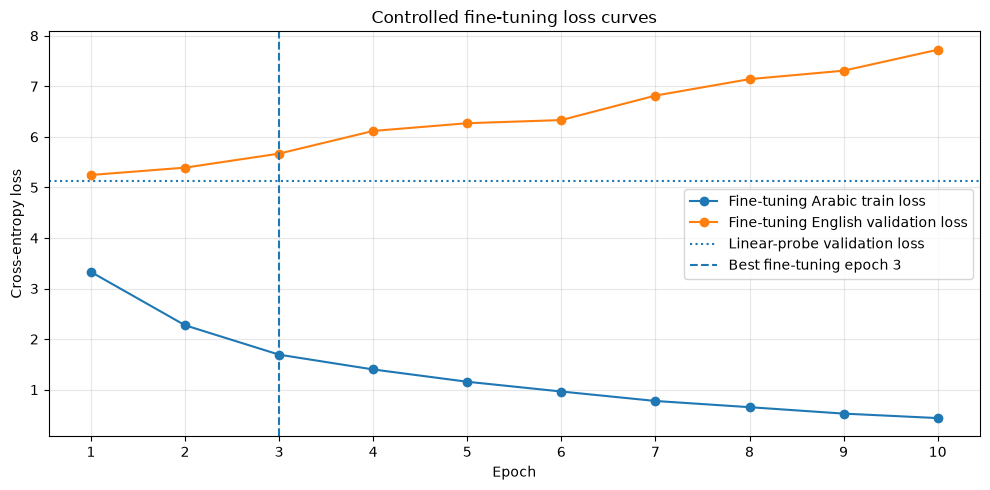

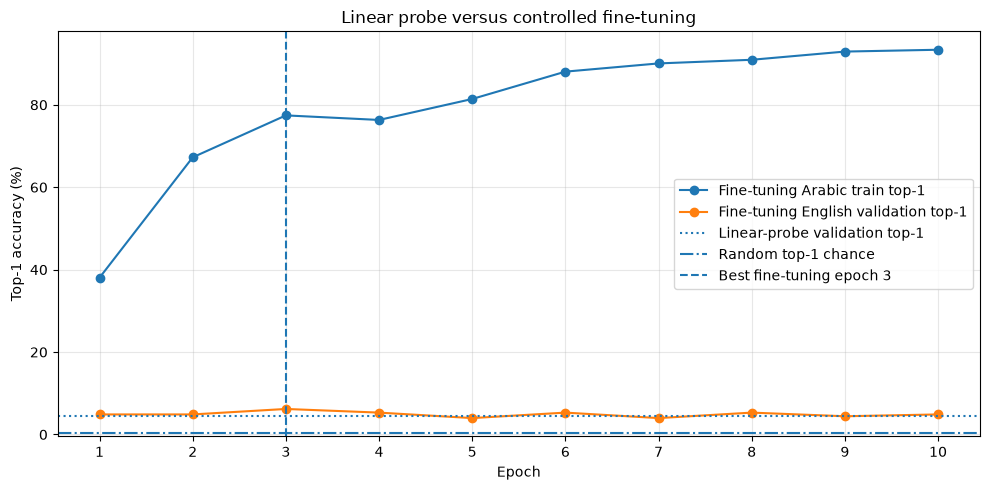

Linear-probe history rows: 15
Loss figure exists: True
Accuracy figure exists: True


In [17]:
LINEAR_PROBE_HISTORY_PATH = (
    PROJECT_ROOT
    / "reports"
    / "supervised_baseline"
    / "resnet18_linear_probe_history.csv"
)

linear_history_df = pd.read_csv(
    LINEAR_PROBE_HISTORY_PATH
)

if "train_top1_percent" not in linear_history_df.columns:
    linear_history_df["train_top1_percent"] = (
        linear_history_df["train_top1_accuracy"] * 100
    )

if "validation_top1_percent" not in linear_history_df.columns:
    linear_history_df["validation_top1_percent"] = (
        linear_history_df["validation_top1_accuracy"] * 100
    )

loss_figure_path = (
    REPORT_DIR
    / "resnet18_layer4_finetuning_loss_curves.png"
)

accuracy_figure_path = (
    REPORT_DIR
    / "resnet18_layer4_finetuning_accuracy_comparison.png"
)

plt.figure(figsize=(10, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Fine-tuning Arabic train loss",
)

plt.plot(
    history_df["epoch"],
    history_df["validation_loss"],
    marker="o",
    label="Fine-tuning English validation loss",
)

plt.axhline(
    linear_probe_metrics[
        "english_variable_validation"
    ]["loss"],
    linestyle=":",
    label="Linear-probe validation loss",
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best fine-tuning epoch {best_epoch}",
)

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Controlled fine-tuning loss curves")
plt.xticks(history_df["epoch"])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(
    loss_figure_path,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

plt.figure(figsize=(10, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_top1_percent"],
    marker="o",
    label="Fine-tuning Arabic train top-1",
)

plt.plot(
    history_df["epoch"],
    history_df["validation_top1_percent"],
    marker="o",
    label="Fine-tuning English validation top-1",
)

plt.axhline(
    linear_probe_metrics[
        "english_variable_validation"
    ]["top1_accuracy"] * 100,
    linestyle=":",
    label="Linear-probe validation top-1",
)

plt.axhline(
    100 / NUM_CLASSES,
    linestyle="-.",
    label="Random top-1 chance",
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best fine-tuning epoch {best_epoch}",
)

plt.xlabel("Epoch")
plt.ylabel("Top-1 accuracy (%)")
plt.title("Linear probe versus controlled fine-tuning")
plt.xticks(history_df["epoch"])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(
    accuracy_figure_path,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print("Linear-probe history rows:", len(linear_history_df))
print("Loss figure exists:", loss_figure_path.exists())
print("Accuracy figure exists:", accuracy_figure_path.exists())

In [18]:
@torch.inference_mode()
def collect_prediction_details(
    model,
    loader,
    label_lookup,
    class_to_writer,
    device,
    condition,
):
    model.eval()

    records = []

    for batch in loader:
        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        labels = get_writer_labels(
            batch,
            label_lookup,
            device,
        )

        logits = model(images)
        probabilities = torch.softmax(
            logits,
            dim=1,
        )

        sorted_classes = logits.argsort(
            dim=1,
            descending=True,
        )

        predicted_classes = sorted_classes[:, 0]

        true_ranks = (
            sorted_classes
            == labels.unsqueeze(1)
        ).to(torch.long).argmax(dim=1) + 1

        predicted_confidences = probabilities.gather(
            1,
            predicted_classes.unsqueeze(1),
        ).squeeze(1)

        for index in range(images.shape[0]):
            true_class = labels[index].item()
            predicted_class = predicted_classes[index].item()
            true_rank = true_ranks[index].item()

            records.append(
                {
                    "condition": condition,
                    "filename": batch["filename"][index],
                    "page_id": batch["page_id"][index].item(),
                    "language": batch["language"][index],
                    "same_text": batch["same_text"][index].item(),
                    "true_writer_id": class_to_writer[true_class],
                    "predicted_writer_id": class_to_writer[predicted_class],
                    "true_class": true_class,
                    "predicted_class": predicted_class,
                    "true_rank": true_rank,
                    "top1_correct": int(true_rank == 1),
                    "top5_correct": int(true_rank <= 5),
                    "top10_correct": int(true_rank <= 10),
                    "predicted_confidence": predicted_confidences[index].item(),
                }
            )

    return pd.DataFrame(records)


finetuned_validation_predictions_df = collect_prediction_details(
    model,
    validation_loader,
    writer_label_lookup,
    class_to_writer,
    DEVICE,
    "english_variable_validation",
)

finetuned_test_predictions_df = collect_prediction_details(
    model,
    test_loader,
    writer_label_lookup,
    class_to_writer,
    DEVICE,
    "english_same_test",
)

print(
    "Validation prediction rows:",
    len(finetuned_validation_predictions_df),
)

print(
    "Test prediction rows:",
    len(finetuned_test_predictions_df),
)

print(
    "Prediction columns:",
    finetuned_validation_predictions_df.columns.tolist(),
)

assert len(finetuned_validation_predictions_df) == 226
assert len(finetuned_test_predictions_df) == 226
assert finetuned_validation_predictions_df["true_rank"].between(1, 226).all()
assert finetuned_test_predictions_df["true_rank"].between(1, 226).all()

Validation prediction rows: 226
Test prediction rows: 226
Prediction columns: ['condition', 'filename', 'page_id', 'language', 'same_text', 'true_writer_id', 'predicted_writer_id', 'true_class', 'predicted_class', 'true_rank', 'top1_correct', 'top5_correct', 'top10_correct', 'predicted_confidence']


In [20]:
def summarize_prediction_ranks(predictions):
    reciprocal_ranks = (
        1.0 / predictions["true_rank"]
    )

    return {
        "samples": len(predictions),
        "top1_accuracy_percent": (
            predictions["top1_correct"].mean() * 100
        ),
        "top5_accuracy_percent": (
            predictions["top5_correct"].mean() * 100
        ),
        "top10_accuracy_percent": (
            predictions["top10_correct"].mean() * 100
        ),
        "mean_reciprocal_rank": reciprocal_ranks.mean(),
        "median_true_rank": predictions["true_rank"].median(),
        "mean_true_rank": predictions["true_rank"].mean(),
        "mean_top1_confidence_percent": (
            predictions["predicted_confidence"].mean() * 100
        ),
    }


finetuned_rank_summary = {
    "english_variable_validation": summarize_prediction_ranks(
        finetuned_validation_predictions_df
    ),
    "english_same_test": summarize_prediction_ranks(
        finetuned_test_predictions_df
    ),
}

finetuned_rank_summary_df = (
    pd.DataFrame(finetuned_rank_summary)
    .T
    .reset_index()
    .rename(columns={"index": "condition"})
)

linear_rank_summary_path = (
    PROJECT_ROOT
    / "reports"
    / "supervised_baseline"
    / "resnet18_linear_probe_rank_summary.csv"
)

linear_rank_summary_df = pd.read_csv(
    linear_rank_summary_path
)

linear_rank_summary_df[
    "mean_top1_confidence_percent"
] = (
    linear_rank_summary_df[
        "mean_top1_confidence"
    ] * 100
)

linear_rank_summary_df = (
    linear_rank_summary_df.drop(
        columns=["mean_top1_confidence"]
    )
)

rank_comparison_df = finetuned_rank_summary_df.merge(
    linear_rank_summary_df,
    on="condition",
    suffixes=(
        "_finetuned",
        "_linear_probe",
    ),
)

rank_comparison_df[
    "top10_change_points"
] = (
    rank_comparison_df[
        "top10_accuracy_percent_finetuned"
    ]
    - rank_comparison_df[
        "top10_accuracy_percent_linear_probe"
    ]
)

rank_comparison_df[
    "mean_rank_change"
] = (
    rank_comparison_df[
        "mean_true_rank_finetuned"
    ]
    - rank_comparison_df[
        "mean_true_rank_linear_probe"
    ]
)

rank_comparison_df[
    "confidence_change_points"
] = (
    rank_comparison_df[
        "mean_top1_confidence_percent_finetuned"
    ]
    - rank_comparison_df[
        "mean_top1_confidence_percent_linear_probe"
    ]
)

display(
    finetuned_rank_summary_df.round(4)
)

display(
    rank_comparison_df[
        [
            "condition",
            "top10_accuracy_percent_linear_probe",
            "top10_accuracy_percent_finetuned",
            "top10_change_points",
            "mean_true_rank_linear_probe",
            "mean_true_rank_finetuned",
            "mean_rank_change",
            "mean_top1_confidence_percent_linear_probe",
            "mean_top1_confidence_percent_finetuned",
            "confidence_change_points",
        ]
    ].round(4)
)

assert np.isclose(
    finetuned_rank_summary[
        "english_variable_validation"
    ]["top1_accuracy_percent"],
    6.194690265486725,
)

assert np.isclose(
    finetuned_rank_summary[
        "english_same_test"
    ]["top1_accuracy_percent"],
    4.424778761061947,
)

,condition,samples,top1_accuracy_percent,top5_accuracy_percent,top10_accuracy_percent,mean_reciprocal_rank,median_true_rank,mean_true_rank,mean_top1_confidence_percent
0,english_variable_validation,226.0,6.1947,14.1593,24.3363,0.1192,36.0,59.8850,15.3232
1,english_same_test,226.0,4.4248,12.8319,20.7965,0.1025,42.0,62.0442,19.0075


,condition,top10_accuracy_percent_linear_probe,top10_accuracy_percent_finetuned,top10_change_points,mean_true_rank_linear_probe,mean_true_rank_finetuned,mean_rank_change,mean_top1_confidence_percent_linear_probe,mean_top1_confidence_percent_finetuned,confidence_change_points
0,english_variable_validation,20.7965,24.3363,3.5398,67.3230,59.8850,-7.4381,2.3487,15.3232,12.9745
1,english_same_test,18.1416,20.7965,2.6549,68.5885,62.0442,-6.5442,2.8508,19.0075,16.1567


In [21]:
print(
    "Comparison columns:",
    rank_comparison_df.columns.tolist(),
)

print(
    "Validation top-10 change:",
    round(
        rank_comparison_df.loc[
            rank_comparison_df["condition"]
            == "english_variable_validation",
            "top10_change_points",
        ].iloc[0],
        4,
    ),
    "percentage points",
)

print(
    "Test top-10 change:",
    round(
        rank_comparison_df.loc[
            rank_comparison_df["condition"]
            == "english_same_test",
            "top10_change_points",
        ].iloc[0],
        4,
    ),
    "percentage points",
)

print(
    "Validation confidence change:",
    round(
        rank_comparison_df.loc[
            rank_comparison_df["condition"]
            == "english_variable_validation",
            "confidence_change_points",
        ].iloc[0],
        4,
    ),
    "percentage points",
)

print(
    "Test confidence change:",
    round(
        rank_comparison_df.loc[
            rank_comparison_df["condition"]
            == "english_same_test",
            "confidence_change_points",
        ].iloc[0],
        4,
    ),
    "percentage points",
)

assert len(rank_comparison_df) == 2
assert rank_comparison_df["condition"].nunique() == 2
assert np.isfinite(
    rank_comparison_df[
        "confidence_change_points"
    ]
).all()

Comparison columns: ['condition', 'samples_finetuned', 'top1_accuracy_percent_finetuned', 'top5_accuracy_percent_finetuned', 'top10_accuracy_percent_finetuned', 'mean_reciprocal_rank_finetuned', 'median_true_rank_finetuned', 'mean_true_rank_finetuned', 'mean_top1_confidence_percent_finetuned', 'samples_linear_probe', 'top1_accuracy_percent_linear_probe', 'top5_accuracy_percent_linear_probe', 'top10_accuracy_percent_linear_probe', 'mean_reciprocal_rank_linear_probe', 'median_true_rank_linear_probe', 'mean_true_rank_linear_probe', 'mean_top1_confidence_percent_linear_probe', 'top10_change_points', 'mean_rank_change', 'confidence_change_points']
Validation top-10 change: 3.5398 percentage points
Test top-10 change: 2.6549 percentage points
Validation confidence change: 12.9745 percentage points
Test confidence change: 16.1567 percentage points


In [22]:
def summarize_prediction_distribution(predictions):
    prediction_counts = (
        predictions["predicted_writer_id"]
        .value_counts()
    )

    probabilities = (
        prediction_counts
        / prediction_counts.sum()
    )

    entropy = -(
        probabilities
        * np.log(probabilities)
    ).sum()

    return {
        "samples": len(predictions),
        "unique_predicted_writers": prediction_counts.size,
        "prediction_coverage_percent": (
            prediction_counts.size
            / NUM_CLASSES
            * 100
        ),
        "maximum_prediction_frequency": int(
            prediction_counts.max()
        ),
        "maximum_prediction_share_percent": (
            prediction_counts.max()
            / len(predictions)
            * 100
        ),
        "prediction_entropy": entropy,
        "normalized_prediction_entropy": (
            entropy
            / np.log(NUM_CLASSES)
        ),
        "mean_confidence_percent": (
            predictions[
                "predicted_confidence"
            ].mean()
            * 100
        ),
    }


linear_validation_predictions_path = (
    PROJECT_ROOT
    / "reports"
    / "supervised_baseline"
    / "english_variable_validation_predictions.csv"
)

linear_test_predictions_path = (
    PROJECT_ROOT
    / "reports"
    / "supervised_baseline"
    / "english_same_test_predictions.csv"
)

linear_validation_predictions_df = pd.read_csv(
    linear_validation_predictions_path
)

linear_test_predictions_df = pd.read_csv(
    linear_test_predictions_path
)

distribution_rows = []

prediction_sets = {
    (
        "linear_probe",
        "english_variable_validation",
    ): linear_validation_predictions_df,
    (
        "linear_probe",
        "english_same_test",
    ): linear_test_predictions_df,
    (
        "layer4_finetuned",
        "english_variable_validation",
    ): finetuned_validation_predictions_df,
    (
        "layer4_finetuned",
        "english_same_test",
    ): finetuned_test_predictions_df,
}

for (
    model_name,
    condition,
), predictions in prediction_sets.items():
    metrics = summarize_prediction_distribution(
        predictions
    )

    distribution_rows.append(
        {
            "model": model_name,
            "condition": condition,
            **metrics,
        }
    )

distribution_comparison_df = pd.DataFrame(
    distribution_rows
)

display(
    distribution_comparison_df.round(4)
)

assert len(distribution_comparison_df) == 4
assert distribution_comparison_df[
    "unique_predicted_writers"
].between(1, NUM_CLASSES).all()
assert np.isfinite(
    distribution_comparison_df[
        "normalized_prediction_entropy"
    ]
).all()

,model,condition,samples,unique_predicted_writers,prediction_coverage_percent,maximum_prediction_frequency,maximum_prediction_share_percent,prediction_entropy,normalized_prediction_entropy,mean_confidence_percent
0,linear_probe,english_variable_validation,226,57,25.2212,33,14.6018,3.4655,0.6393,2.3487
1,linear_probe,english_same_test,226,44,19.4690,35,15.4867,3.0995,0.5718,2.8508
2,layer4_finetuned,english_variable_validation,226,80,35.3982,23,10.1770,3.9934,0.7367,15.3232
3,layer4_finetuned,english_same_test,226,61,26.9912,21,9.2920,3.6355,0.6707,19.0075


,rank,linear_validation,finetuned_validation,linear_test,finetuned_test
0,1,4.4248,6.1947,3.5398,4.4248
4,5,11.9469,14.1593,14.1593,12.8319
9,10,20.7965,24.3363,18.1416,20.7965
19,20,30.5310,36.7257,30.9735,32.3009
49,50,53.0973,59.7345,46.9027,53.9823
99,100,73.8938,76.9912,73.8938,75.6637
225,226,100.0000,100.0000,100.0000,100.0000


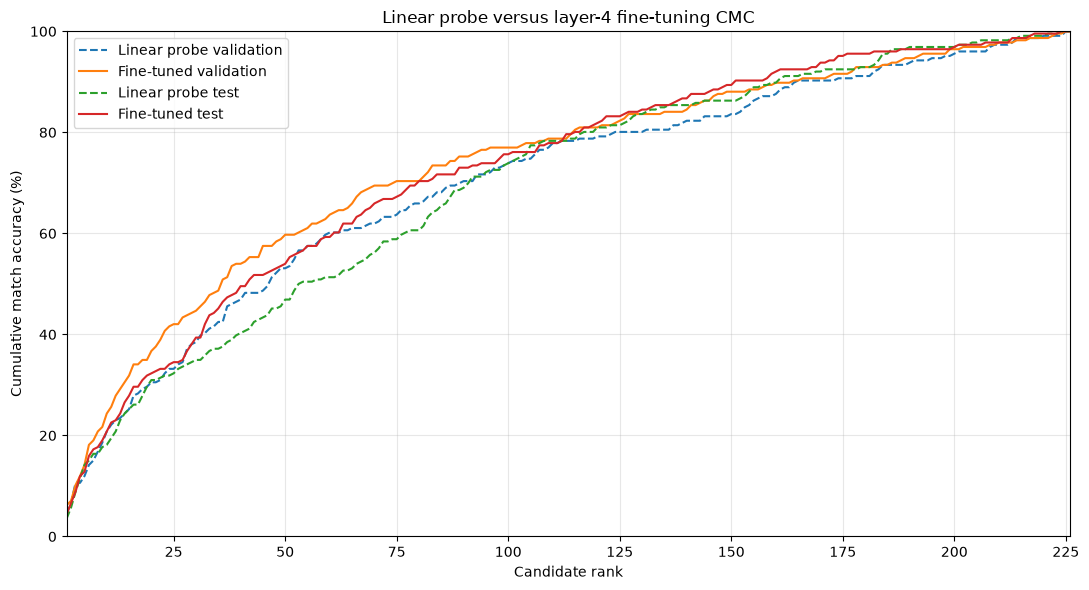

CMC figure path: /home/arijit/Documents/handwriting-cross-script-research/reports/supervised_finetuning/resnet18_layer4_finetuning_cmc_comparison.png
CMC figure exists: True


In [23]:
ranks = np.arange(
    1,
    NUM_CLASSES + 1,
)


def calculate_cmc(predictions):
    return np.array(
        [
            (
                predictions["true_rank"]
                <= rank
            ).mean() * 100
            for rank in ranks
        ]
    )


linear_validation_cmc = calculate_cmc(
    linear_validation_predictions_df
)

linear_test_cmc = calculate_cmc(
    linear_test_predictions_df
)

finetuned_validation_cmc = calculate_cmc(
    finetuned_validation_predictions_df
)

finetuned_test_cmc = calculate_cmc(
    finetuned_test_predictions_df
)

cmc_comparison_df = pd.DataFrame(
    {
        "rank": ranks,
        "linear_validation": linear_validation_cmc,
        "finetuned_validation": finetuned_validation_cmc,
        "linear_test": linear_test_cmc,
        "finetuned_test": finetuned_test_cmc,
    }
)

selected_ranks = [
    1,
    5,
    10,
    20,
    50,
    100,
    226,
]

display(
    cmc_comparison_df[
        cmc_comparison_df["rank"].isin(
            selected_ranks
        )
    ].round(4)
)

cmc_figure_path = (
    REPORT_DIR
    / "resnet18_layer4_finetuning_cmc_comparison.png"
)

plt.figure(figsize=(11, 6))

plt.plot(
    ranks,
    linear_validation_cmc,
    linestyle="--",
    label="Linear probe validation",
)

plt.plot(
    ranks,
    finetuned_validation_cmc,
    label="Fine-tuned validation",
)

plt.plot(
    ranks,
    linear_test_cmc,
    linestyle="--",
    label="Linear probe test",
)

plt.plot(
    ranks,
    finetuned_test_cmc,
    label="Fine-tuned test",
)

plt.xlabel("Candidate rank")
plt.ylabel("Cumulative match accuracy (%)")
plt.title("Linear probe versus layer-4 fine-tuning CMC")
plt.xlim(1, NUM_CLASSES)
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(
    cmc_figure_path,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print(
    "CMC figure path:",
    cmc_figure_path,
)
print(
    "CMC figure exists:",
    cmc_figure_path.exists(),
)

assert linear_validation_cmc[-1] == 100
assert linear_test_cmc[-1] == 100
assert finetuned_validation_cmc[-1] == 100
assert finetuned_test_cmc[-1] == 100

In [24]:
history_path = (
    REPORT_DIR
    / "resnet18_layer4_finetuning_history.csv"
)

final_metrics_path = (
    REPORT_DIR
    / "resnet18_layer4_finetuning_final_metrics.csv"
)

model_comparison_path = (
    REPORT_DIR
    / "linear_probe_vs_layer4_finetuning_metrics.csv"
)

rank_summary_path = (
    REPORT_DIR
    / "resnet18_layer4_finetuning_rank_summary.csv"
)

rank_comparison_path = (
    REPORT_DIR
    / "linear_probe_vs_layer4_finetuning_rank_comparison.csv"
)

distribution_comparison_path = (
    REPORT_DIR
    / "linear_probe_vs_layer4_finetuning_prediction_distribution.csv"
)

cmc_comparison_path = (
    REPORT_DIR
    / "linear_probe_vs_layer4_finetuning_cmc.csv"
)

validation_predictions_path = (
    REPORT_DIR
    / "english_variable_validation_predictions.csv"
)

test_predictions_path = (
    REPORT_DIR
    / "english_same_test_predictions.csv"
)

summary_path = (
    REPORT_DIR
    / "resnet18_layer4_finetuning_summary.json"
)

history_df.to_csv(
    history_path,
    index=False,
)

best_finetuned_metrics_df.to_csv(
    final_metrics_path,
    index=False,
)

comparison_df.to_csv(
    model_comparison_path,
    index=False,
)

finetuned_rank_summary_df.to_csv(
    rank_summary_path,
    index=False,
)

rank_comparison_df.to_csv(
    rank_comparison_path,
    index=False,
)

distribution_comparison_df.to_csv(
    distribution_comparison_path,
    index=False,
)

cmc_comparison_df.to_csv(
    cmc_comparison_path,
    index=False,
)

finetuned_validation_predictions_df.to_csv(
    validation_predictions_path,
    index=False,
)

finetuned_test_predictions_df.to_csv(
    test_predictions_path,
    index=False,
)


def make_json_safe(value):
    if isinstance(value, dict):
        return {
            key: make_json_safe(item)
            for key, item in value.items()
        }

    if isinstance(value, list):
        return [
            make_json_safe(item)
            for item in value
        ]

    if isinstance(value, tuple):
        return [
            make_json_safe(item)
            for item in value
        ]

    if isinstance(value, np.integer):
        return int(value)

    if isinstance(value, np.floating):
        return (
            float(value)
            if np.isfinite(value)
            else None
        )

    if isinstance(value, float):
        return (
            value
            if np.isfinite(value)
            else None
        )

    if isinstance(value, np.bool_):
        return bool(value)

    return value


experiment_summary = {
    "experiment": "controlled_resnet18_layer4_cross_script_finetuning",
    "dataset": "QUWI",
    "task": "closed_set_cross_script_writer_identification",
    "initial_checkpoint": str(
        LINEAR_PROBE_CHECKPOINT_PATH
    ),
    "best_checkpoint": str(
        best_checkpoint_path
    ),
    "training_script": "Arabic",
    "training_pages": [1, 2],
    "validation_script": "English",
    "validation_page": 3,
    "validation_text_condition": "variable",
    "test_script": "English",
    "test_page": 4,
    "test_text_condition": "same",
    "writers": NUM_CLASSES,
    "training_images": len(
        arabic_train_dataset
    ),
    "validation_images": len(
        english_variable_validation_dataset
    ),
    "test_images": len(
        english_same_test_dataset
    ),
    "target_size": [384, 384],
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "best_epoch": best_epoch,
    "trainable_backbone_block": "layer4",
    "batchnorm_statistics": "frozen",
    "backbone_learning_rate": BACKBONE_LEARNING_RATE,
    "classifier_learning_rate": CLASSIFIER_LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "maximum_gradient_norm": MAXIMUM_GRADIENT_NORM,
    "mixed_precision": scaler.is_enabled(),
    "training_peak_gpu_memory_mb": training_peak_gpu_memory_mb,
    "nonfinite_gradient_norm_epochs": nonfinite_gradient_epochs,
    "linear_probe_metrics": linear_probe_metrics,
    "finetuned_metrics": best_finetuned_metrics,
    "finetuned_rank_metrics": finetuned_rank_summary,
    "history": history_df.to_dict(
        orient="records"
    ),
    "report_files": [
        history_path.name,
        final_metrics_path.name,
        model_comparison_path.name,
        rank_summary_path.name,
        rank_comparison_path.name,
        distribution_comparison_path.name,
        cmc_comparison_path.name,
        validation_predictions_path.name,
        test_predictions_path.name,
        loss_figure_path.name,
        accuracy_figure_path.name,
        cmc_figure_path.name,
    ],
}

with summary_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        make_json_safe(
            experiment_summary
        ),
        file,
        indent=2,
    )

saved_report_paths = [
    history_path,
    final_metrics_path,
    model_comparison_path,
    rank_summary_path,
    rank_comparison_path,
    distribution_comparison_path,
    cmc_comparison_path,
    validation_predictions_path,
    test_predictions_path,
    summary_path,
    loss_figure_path,
    accuracy_figure_path,
    cmc_figure_path,
]

for path in saved_report_paths:
    print(
        path.name,
        ":",
        path.exists(),
    )

assert all(
    path.exists()
    for path in saved_report_paths
)

resnet18_layer4_finetuning_history.csv : True
resnet18_layer4_finetuning_final_metrics.csv : True
linear_probe_vs_layer4_finetuning_metrics.csv : True
resnet18_layer4_finetuning_rank_summary.csv : True
linear_probe_vs_layer4_finetuning_rank_comparison.csv : True
linear_probe_vs_layer4_finetuning_prediction_distribution.csv : True
linear_probe_vs_layer4_finetuning_cmc.csv : True
english_variable_validation_predictions.csv : True
english_same_test_predictions.csv : True
resnet18_layer4_finetuning_summary.json : True
resnet18_layer4_finetuning_loss_curves.png : True
resnet18_layer4_finetuning_accuracy_comparison.png : True
resnet18_layer4_finetuning_cmc_comparison.png : True


## Experiment conclusion

This notebook compared a frozen ResNet-18 linear probe with controlled partial fine-tuning under the same Arabic-to-English closed-set writer-identification protocol.

The best fine-tuned checkpoint was selected at epoch 3. Only ResNet layer 4 and the 226-class writer classifier were trainable. Earlier backbone layers remained frozen, and all backbone BatchNorm running statistics were kept fixed.

### Best fine-tuning results

- Arabic training top-1 accuracy: 90.49%
- English variable-text validation top-1 accuracy: 6.19%
- English same-text test top-1 accuracy: 4.42%
- English variable-text validation top-5 accuracy: 14.16%
- English same-text test top-5 accuracy: 12.83%
- English variable-text validation top-10 accuracy: 24.34%
- English same-text test top-10 accuracy: 20.80%

### Comparison with the frozen linear probe

Fine-tuning improved:

- Validation top-1 by 1.77 percentage points
- Test top-1 by 0.89 percentage points
- Validation top-10 by 3.54 percentage points
- Test top-10 by 2.65 percentage points
- Validation mean true-writer rank from 67.32 to 59.89
- Test mean true-writer rank from 68.59 to 62.04

Prediction coverage also increased:

- Validation coverage: 25.22% to 35.40%
- Test coverage: 19.47% to 26.99%

This indicates that layer-4 adaptation reduced partial class collapse and improved overall writer ranking.

### Limitations

The improvement was accompanied by severe overfitting. Arabic training top-1 accuracy reached more than 90%, while English validation accuracy remained close to 6%.

Cross-entropy loss became worse than the linear-probe baseline:

- Validation loss: 5.12 to 5.67
- Test loss: 5.14 to 6.11

Mean top-1 confidence increased sharply:

- Validation confidence: 2.35% to 15.32%
- Test confidence: 2.85% to 19.01%

Therefore, fine-tuning produced better ranking for some samples but also substantially greater overconfidence and poorer calibration.

Non-finite pre-clipping gradient norms occurred during epochs 1 and 4 under mixed-precision training. Gradient clipping and automatic loss scaling allowed training to continue, but future experiments should use stricter numerical monitoring.

### Main finding

Controlled layer-4 fine-tuning provides a small improvement over the frozen linear probe, but supervised Arabic-only classification does not learn robust script-invariant writer representations. The large Arabic-to-English generalization gap remains the dominant limitation.

This result motivates moving from closed-set writer classification toward writer-disjoint metric learning and self-supervised representation learning, where the model is trained to produce transferable writer embeddings rather than memorize a fixed set of writer classes.